# Part I.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("data/assignment01_digital_services.csv")
display(df.head())

,observation_id,service,latency_ms,alert_type
0,1,orders,112.70,none
1,2,orders,109.83,none
2,3,telemetry,99.02,none
3,4,telemetry,94.44,none
4,5,telemetry,97.09,none


Observational unit: one logged API request/response event.
Population: all API requests handled by the orders, telemetry and identity services during the logging window; these 144 rows are a sample of it.

| Variable       | Type                                       |
|----------------|--------------------------------------------|
| observation_id | identifier (not a variable to analyse)     |
| service        | categorical, nominal — 3 levels            |
| latency_ms     | quantitative, continuous (ms, ratio scale) |
| alert_type     | categorical, nominal — 4 levels            |

observation_id is stored as int64 but is not quantitative — n_unique == n_rows marks it as a label.

In [9]:
display(pd.DataFrame({
    "dtype":    df.dtypes,
    "missing":  df.isna().sum(),
    "n_unique": df.nunique(),
    "example":  df.iloc[0],
}))

display(df["service"].value_counts())
print("observation_id unique on every row:", df["observation_id"].is_unique)

,dtype,missing,n_unique,example
observation_id,int64,0,144,1
service,str,0,3,orders
latency_ms,float64,0,143,112.7
alert_type,str,0,4,none


service
orders       50
identity     49
telemetry    45
Name: count, dtype: int64

observation_id unique on every row: True


In [10]:
freq = df["alert_type"].value_counts().to_frame("count")
freq["percent"] = (100 * freq["count"] / len(df)).round(2)
display(freq)

,count,percent
alert_type,,
none,104,72.22
authentication,25,17.36
rate_limit,9,6.25
injection_signature,6,4.17


In [11]:
def summary(x):
    q1, q3 = x.quantile([0.25, 0.75])
    return pd.Series({"n": x.size, "mean": x.mean(), "median": x.median(), "sd": x.std(),
                      "min": x.min(), "Q1": q1, "Q3": q3, "max": x.max(), "IQR": q3 - q1})

display(pd.concat([
    summary(df["latency_ms"]).to_frame("all").T,
    df.groupby("service")["latency_ms"].apply(summary).unstack(),
]).round(2))

,n,mean,median,sd,min,Q1,Q3,max,IQR
all,144.0,110.11,106.93,23.10,75.21,95.84,116.88,223.80,21.04
identity,49.0,96.07,93.72,16.12,75.21,85.39,105.10,154.27,19.71
orders,50.0,122.20,114.52,24.81,98.53,109.84,124.15,223.80,14.31
telemetry,45.0,111.97,106.92,19.38,86.78,97.95,116.83,177.87,18.88


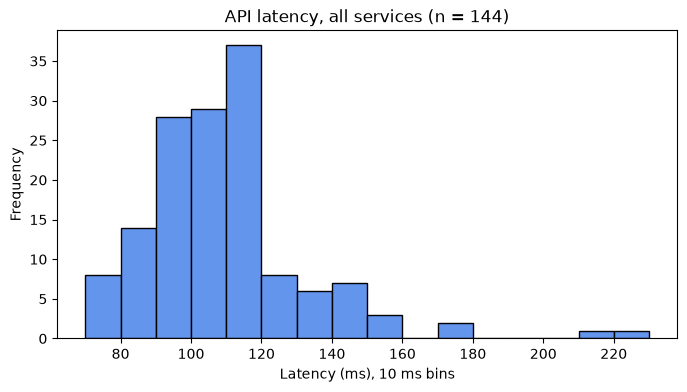

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["latency_ms"], bins=np.arange(70, 235, 10), color="cornflowerblue", edgecolor="black")
ax.set(xlabel="Latency (ms), 10 ms bins", ylabel="Frequency",
       title="API latency, all services (n = 144)")
plt.show()

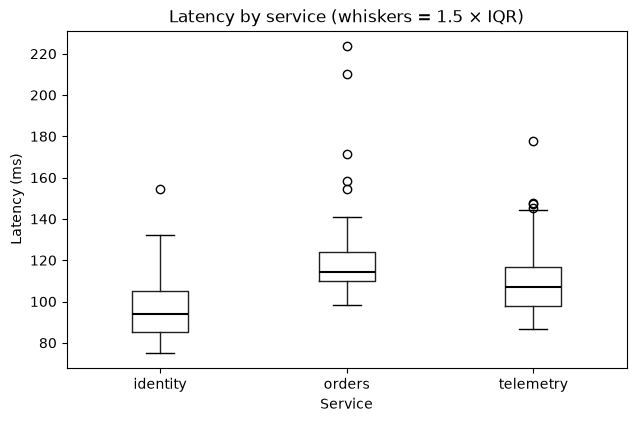

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
df.boxplot(column="latency_ms", by="service", ax=ax, grid=False,
           medianprops=dict(color="black", linewidth=1.5))
ax.set(xlabel="Service", ylabel="Latency (ms)", title="Latency by service (whiskers = 1.5 × IQR)")
fig.suptitle("") # pandas adds its own title; drop it
plt.show()

Histogram. x = latency in ms, cut into 10 ms bins from 70 to 230; y = frequency, the count of observations per bin. Bars touch because latency is continuous. The shape is unimodal with its peak in the 110–120 ms bin (37 obs), about two thirds of the data between 90 and 120 ms, a short left tail ending at 75.2 ms, and a long sparse right tail reaching 223.8 ms — clearly right-skewed, as response times usually are: bounded below, unbounded above.

Boxplots. The line in each box is the median (93.7 / 114.5 / 106.9 for identity / orders / telemetry). The box spans Q1–Q3, holding the middle 50% of that service's data; its height is the IQR. The whiskers reach the most extreme value still within 1.5×IQR of the nearer quartile — so they are not the min and max when outliers are present. The circles are those flagged values, drawn individually; all ten sit above the upper fence, none below. In all three boxes the median sits below the centre, the visual signature of the right skew.

In [14]:
g = df.groupby("service")["latency_ms"]
q1 = g.transform("quantile", 0.25)
q3 = g.transform("quantile", 0.75)
iqr = q3 - q1

df["outlier"] = (df["latency_ms"] < q1 - 1.5 * iqr) | (df["latency_ms"] > q3 + 1.5 * iqr)

fences = df.groupby("service")["latency_ms"].quantile([0.25, 0.75]).unstack()
fences.columns = ["Q1", "Q3"]
fences["IQR"] = fences["Q3"] - fences["Q1"]
fences["lower"] = fences["Q1"] - 1.5 * fences["IQR"]
fences["upper"] = fences["Q3"] + 1.5 * fences["IQR"]
display(fences.round(2))

,Q1,Q3,IQR,lower,upper
service,,,,,
identity,85.39,105.10,19.71,55.83,134.66
orders,109.84,124.15,14.31,88.37,145.61
telemetry,97.95,116.83,18.88,69.63,145.15


In [15]:
display(df[df["outlier"]].sort_values(["service", "latency_ms"]))
display(df["outlier"].value_counts())

,observation_id,service,latency_ms,alert_type,outlier
131,132,identity,154.27,none,True
86,87,orders,154.32,authentication,True
65,66,orders,158.59,none,True
59,60,orders,171.59,rate_limit,True
18,19,orders,210.10,none,True
87,88,orders,223.80,injection_signature,True
38,39,telemetry,145.52,none,True
32,33,telemetry,147.26,authentication,True
119,120,telemetry,147.79,none,True
132,133,telemetry,177.87,none,True


outlier
False    134
True      10
Name: count, dtype: int64

In [18]:
display(pd.crosstab(df["outlier"], df["alert_type"], normalize="index").round(3))

alert_type,authentication,injection_signature,none,rate_limit
outlier,,,,
False,0.172,0.037,0.731,0.06
True,0.200,0.100,0.600,0.10


10 of 144 observations (6.9%) are flagged, all above the upper fence. All are retained; every summary above is computed on the full sample.

A plotted outlier is not automatically a data error. The 1.5×IQR rule is mechanical, it knows nothing about how the data arose, and it assumes rough symmetry, so on a right-skewed variable like latency it flags tail values by construction, even in perfectly clean data. These values are also entirely plausible for the process: a 210 ms response is what a retry, a cold cache or a GC pause looks like; there are no negatives, zeros or impossible magnitudes. And they are disproportionately alert-carrying (the two largest orders values sit on a rate_limit and an injection_signature alert), so they are likely the signal a performance or security analysis is after. Deleting a point needs external evidence of a recording fault a known logging bug, a broken sensor, an impossible value never the boxplot alone.

In [17]:
tab = df.groupby("service")["latency_ms"].apply(summary).unstack()
tab["mean − median"] = tab["mean"] - tab["median"]
tab["range"] = tab["max"] - tab["min"]
display(tab[["median", "mean", "mean − median", "sd", "IQR", "range"]].round(2))

,median,mean,mean − median,sd,IQR,range
service,,,,,,
identity,93.72,96.07,2.35,16.12,19.71,79.06
orders,114.52,122.20,7.67,24.81,14.31,125.27
telemetry,106.92,111.97,5.05,19.38,18.88,91.09


Typical latency. Both measures of centre rank the services the same way: identity fastest (median 93.7 ms), telemetry in the middle (106.9), orders slowest (114.5). The fastest-to-slowest gap of ~21 ms is about one IQR — visible, but the orders and telemetry boxes overlap heavily, so many individual telemetry requests are slower than many orders requests.

Spread. The two measures disagree, and that is itself the finding. By sd, orders is the most variable (24.81 vs 16.12 for identity); by IQR, orders is the least variable (14.31, the tightest middle 50%). The sd is squared-distance based and absorbs the two 200+ ms tail values, while the IQR ignores them. Read together: orders is very consistent in its core behaviour but has by far the worst tail (range 125 ms, and the five largest flagged values in the dataset).

Skewness and mean vs median. All three are right-skewed, and in all three mean > median. The gap widens with the severity of the tail: +2.35 (identity), +5.05 (telemetry), +7.67 (orders). The mean therefore overstates the typical request everywhere, and most for orders — the median is the better single-number summary here.

What cannot be generalised. These are descriptive statistics of 144 sampled observations. There is no test, p-value or confidence interval, so nothing here shows the population medians differ — with n ≈ 45–50 per group the sampling variability is unquantified. Nor is anything causal: service is not randomly assigned, and the three handle different workloads, payload sizes and dependency chains, any of which could produce the gap; likewise an injection_signature alert co-occurring with 223.8 ms does not mean it caused the delay. With no timestamps or load information in the file, the summaries cannot be extended to other time windows, traffic levels or releases. And because the distributions overlap substantially, knowing a request's service is a weak predictor of its individual latency.

# Part II.

a. Identify the observational unit and variables. For indoor_temp_c and energy_kwh, report 
, mean, median, and sample standard deviation separately for each zone.

In [21]:
df2 = pd.read_csv("data/assignment01_smart_building.csv")
display(df2.head())


,measurement_id,hour,zone,outdoor_temp_c,indoor_temp_c,energy_kwh
0,1,1,north,2.14,21.02,41.31
1,2,2,north,1.37,19.99,39.36
2,3,3,north,1.35,20.39,43.58
3,4,4,north,1.59,19.98,45.55
4,5,5,north,2.30,20.74,41.09


Observational unit: one hourly reading taken in one zone of the *building*.
Population: all hourly readings the building's sensors could produce; these 96 rows (2 zones × 48 hours = 2 days) are a sample of it.

| Variable        | Type                                        |
|-----------------|----------------------------------------------|
| measurement_id  | identifier (not a variable to analyse)      |
| hour            | quantitative, discrete — hour index 1–48 within the 2-day window |
| zone            | categorical, nominal — 2 levels (north, south) |
| outdoor_temp_c  | quantitative, continuous (°C, interval scale) |
| indoor_temp_c   | quantitative, continuous (°C, interval scale) |
| energy_kwh      | quantitative, continuous (kWh, ratio scale)  |

measurement_id is stored as int64 but is not quantitative — n_unique == n_rows marks it as a label.


In [ ]:
def center_spread(x):
    return pd.Series({"n": x.size, "mean": x.mean(), "median": x.median(), "sd": x.std()})

for col in ["indoor_temp_c", "energy_kwh"]:
    print(col)
    display(df2.groupby("zone")[col].apply(center_spread).unstack().round(2))


indoor_temp_c


,n,mean,median,sd
zone,,,,
north,48.0,21.28,21.24,0.61
south,48.0,22.27,22.28,0.55


energy_kwh


,n,mean,median,sd
zone,,,,
north,48.0,39.45,39.84,3.98
south,48.0,37.33,37.08,4.15


b. Plot indoor temperature against hour, using a separate line for each zone. Describe the time pattern and explain what each axis and line represent.

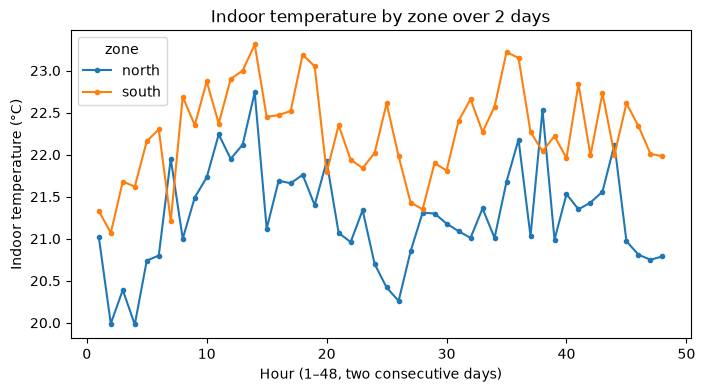

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
for zone, group in df2.groupby("zone"):
    ax.plot(group["hour"], group["indoor_temp_c"], marker="o", markersize=3, label=zone)
ax.set(xlabel="Hour (1–48, two consecutive days)", ylabel="Indoor temperature (°C)",
       title="Indoor temperature by zone over 2 days")
ax.legend(title="zone")
plt.show()


x = hour, the hour index (1–48) spanning the two consecutive logged days; y = indoor_temp_c, the zone's indoor temperature in °C; each line traces one zone (north, south) across the full 48-hour window.

Both lines show the same daily cycle twice: 
- a trough in the early morning followed by a rise to a mid-afternoon peak  then a decline back toward the next morning's trough — and the pattern repeats on day 2.

- consistent with normal daytime heating/occupancy followed by night-time cooldown. The south line sits consistently above the north line by roughly 1°C at almost every hour, so we could suggest that South is being a sunny side of a smart house

c. Create a scatterplot of outdoor_temp_c against energy_kwh, using colour or separate panels for the zones. Describe the direction, form, strength, and unusual points visible in the association.

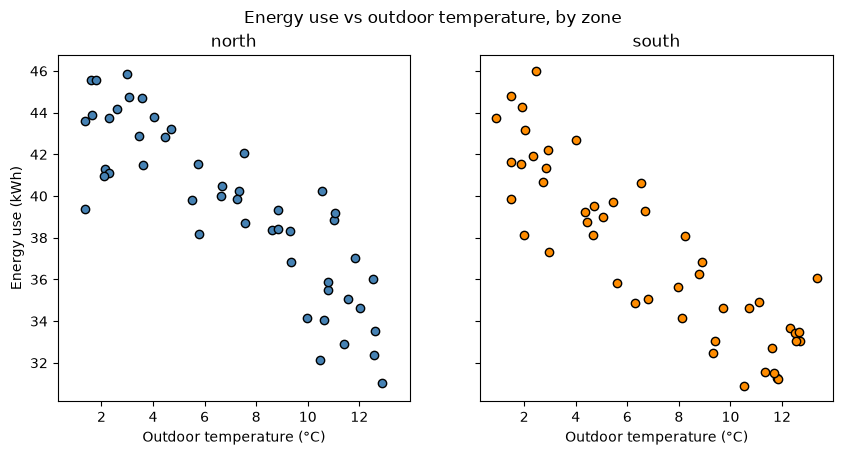

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
colors = {"north": "steelblue", "south": "darkorange"}
for ax, (zone, group) in zip(axes, df2.groupby("zone")):
    ax.scatter(group["outdoor_temp_c"], group["energy_kwh"], color=colors[zone], edgecolor="black")
    ax.set(xlabel="Outdoor temperature (°C)", title=zone)
axes[0].set_ylabel("Energy use (kWh)")
fig.suptitle("Energy use vs outdoor temperature, by zone")
plt.show()


Direction: negative in both zones — energy use falls as outdoor temperature rises. Form: linear, no curvature. Strength: strong (r ≈ −0.86 north, −0.88 south). Unusual points: none stand out; both panels are a fairly tight, evenly scattered band around the trend line with no clear outliers.


Conclusion. Indoor temperature is tightly controlled in both zones (sd around half a degree), cycling gently with the time of day rather than drifting, which points to active climate control rather than a passive response to the outdoors. The two zones are consistently offset from one another — south a degree or so warmer than north at almost every hour, and correspondingly using somewhat less energy on average — so whatever distinguishes the zones (orientation, insulation, equipment, occupancy) shows up as a stable gap rather than an occasional one. Against this backdrop, energy use tracks outdoor temperature closely: warmer outdoor hours line up with lower energy use and colder hours with higher use, in both zones alike, with no stray points breaking the pattern. Taken together, the building appears to hold each zone at a steady indoor target while energy demand rises and falls with how hard it has to work against the weather outside.
